In [1]:
# =============================================================================
# COMPLETE PROJECT: AI Factuality Detection for Educational Content
#  Detect Factual/Contradiction/Irrelevant Answers
# Dataset: /data/datalab_export_2026-03-06 09_53_55.csv
# Target: 3-class classification (factual=0, contradiction=1, irrelevant=2)
# Approach: EDA -> Feature Eng (TF-IDF + spaCy NLP) -> Balance -> Train/Eval
# Outputs: models.pkl, predictions.csv, confusion_matrix.png, feature_importance.csv
# =============================================================================

# =============================================================================
# ALL IMPORTS AT TOP (as requested)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import spacy
from spacy.matcher import Matcher
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load spaCy English model for NLP features (small model for speed;)
nlp = spacy.load('en_core_web_sm')

print("All imports loaded. spaCy model ready.")



All imports loaded. spaCy model ready.


In [2]:
# =============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# =============================================================================
df = pd.read_json('./data/factual_check_train_data.json')
df


,answer,type,context,question
0,"In 1512, Parliament passed a significant act t...",factual,During the Hundred Years' War a French attack ...,In what year did Parliament pass a notable law...
1,The Spanish and French were the ones who estab...,factual,"""By May 1539, Conquistador Hernando de Soto sk...",Who established early settlements in Florida
2,"Traditionally, monsoons in Punjab are expected...",factual,The onset of the southwest monsoon is anticipa...,When do monsoons traditionally happen in Punjab?
3,The media made the requests for Kondo to use o...,factual,Media requests at the trade show prompted Kond...,Who made the requests for Kondo to use orchest...
4,According to historians Robert Friedel and Pau...,factual,In addressing the question of who invented the...,How many inventors came up with electric lamps...
...,...,...,...,...
21016,"At the first proceeding, the jury determines w...",factual,"In 1976, contemporaneously with Woodson and Ro...",What is decided at the first proceeding?
21017,King Henry VII of England commissioned John Ca...,factual,The foundations of the British Empire were lai...,Who commissioned John Cabot's voyage?
21018,The distinguishing visual design feature of Fr...,irrelevant,The fossil record suggests that the last few m...,What suggests that the last few million years ...
21019,"For group law and topology to integrate well, ...",irrelevant,"Following the highly publicized incident, West...",What industry did Kanye turn to after taking a...


In [3]:
# Clean column names and data (strip whitespace, lowercase types for consistency)
df.columns = df.columns.str.strip().str.lower()
df['type'] = df['type'].str.strip().str.lower()

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nType distribution (severe imbalance noted - factual dominates):")
print(df['type'].value_counts())

Dataset shape: (21021, 4)
Columns: ['answer', 'type', 'context', 'question']

Type distribution (severe imbalance noted - factual dominates):
type
factual          17431
contradiction     1818
irrelevant        1772
Name: count, dtype: int64


In [4]:
# Map categorical labels to integers: factual=0, contradiction=1, irrelevant=2
type_mapping = {'factual': 0, 'contradiction': 1, 'irrelevant': 2}
df['label'] = df['type'].map(type_mapping)
print("\n Label distribution:")
print(df['label'].value_counts().sort_index())


 Label distribution:
label
0    17431
1     1818
2     1772
Name: count, dtype: int64


In [5]:
# Handle missing values (fill empty strings for text fields)
df['question'] = df['question'].fillna('')
df['answer'] = df['answer'].fillna('')
df['context'] = df['context'].fillna('')

In [6]:
# Quick text stats
df['q_len'] = df['question'].str.len()
df['a_len'] = df['answer'].str.len()
df['c_len'] = df['context'].str.len()
print(f"\n Text length stats:\n{df[['q_len', 'a_len', 'c_len']].describe()}")




 Text length stats:
              q_len         a_len         c_len
count  21021.000000  21021.000000  21021.000000
mean      59.381143     89.662718    686.349127
std       21.349175     44.490616    360.602114
min       12.000000      1.000000      0.000000
25%       44.000000     62.000000    526.000000
50%       56.000000     83.000000    665.000000
75%       71.000000    110.000000    867.000000
max      201.000000    642.000000   3706.000000


In [7]:
# Save cleaned data
df.to_csv('cleaned_train_data.csv', index=False)
print("Cleaned data saved: cleaned_train_data.csv")

Cleaned data saved: cleaned_train_data.csv


In [8]:
# =============================================================================
# STEP 2: NLP FEATURE ENGINEERING WITH SPACY
# Goal: Extract semantic/lexical features to capture factuality better than bag-of-words
# Features: entity overlap, POS overlap, semantic similarity (via spaCy vectors), keyword match
# =============================================================================
def extract_nlp_features_fixed(row):
    """
    FIXED VERSION: 
    - POS overlap: set(pos_q).union(set(pos_a)) instead of list | list
    - Entity/lexical: .intersection()/.union() for safety
    - Semantic: Better fallback if no vectors (empty docs)
    - Negation: sum() count instead of list comp for speed
    Returns 7 features as list.
    """
    q_doc = nlp(row['question'])
    a_doc = nlp(row['answer'])
    c_doc = nlp(row['context'])
    
    # 1. Entity overlap (NER: PERSON/DATE/ORG)
    entities_q = set(ent.text.lower() for ent in q_doc.ents)
    entities_a = set(ent.text.lower() for ent in a_doc.ents)
    entities_c = set(ent.text.lower() for ent in c_doc.ents)
    ent_overlap_qa = len(entities_q.intersection(entities_a)) / max(len(entities_q.union(entities_a)), 1)
    ent_overlap_ac = len(entities_a.intersection(entities_c)) / max(len(entities_a.union(entities_c)), 1)
    
    # 2. POS overlap (proper set union/intersection)
    pos_q = [token.pos_ for token in q_doc]
    pos_a = [token.pos_ for token in a_doc]
    pos_set_q = set(pos_q)
    pos_set_a = set(pos_a)
    pos_overlap = len(pos_set_q.intersection(pos_set_a)) / max(len(pos_set_q.union(pos_set_a)), 1)
    
    # 3. Semantic similarity (spaCy doc.similarity; 0 fallback)
    sim_qa = q_doc.similarity(a_doc) if len(q_doc) > 0 and len(a_doc) > 0 else 0.0
    sim_ac = a_doc.similarity(c_doc) if len(a_doc) > 0 and len(c_doc) > 0 else 0.0
    
    # 4. Lexical Jaccard (token sets)
    tokens_q = set(q_doc.text.lower().split())
    tokens_a = set(a_doc.text.lower().split())
    jaccard_qa = len(tokens_q.intersection(tokens_a)) / max(len(tokens_q.union(tokens_a)), 1)
    
    # 5. Negation mismatch (binary flag)
    neg_words = {'no', 'not', 'never', 'none', 'nothing', 'neither'}
    neg_q = sum(1 for token in q_doc if token.lower_ in neg_words)
    neg_a = sum(1 for token in a_doc if token.lower_ in neg_words)
    neg_mismatch = 1 if abs(neg_q - neg_a) > 0 else 0
    
    return [ent_overlap_qa, ent_overlap_ac, pos_overlap, sim_qa, sim_ac, jaccard_qa, neg_mismatch]



In [9]:
# Apply NLP features (batched for speed; ~10s for 100 samples, scales to 21k)
print("Extracting FIXED spaCy NLP features...")
nlp_features = np.array([extract_nlp_features_fixed(row) for _, row in df.iterrows()])
nlp_df = pd.DataFrame(nlp_features, columns=['ent_ov_qa', 'ent_ov_ac', 'pos_ov', 'sim_qa', 'sim_ac', 'jacc_qa', 'neg_mis'])
df_nlp = pd.concat([df.reset_index(drop=True), nlp_df.reset_index(drop=True)], axis=1)

print("NLP feature stats (high values = likely factual):")
print(nlp_df.describe())
df_nlp.to_csv('nlp_features_fixed.csv', index=False)
print("Saved: nlp_features_fixed.csv")



Extracting FIXED spaCy NLP features...
NLP feature stats (high values = likely factual):
          ent_ov_qa     ent_ov_ac        pos_ov        sim_qa        sim_ac  \
count  21021.000000  21021.000000  21021.000000  21021.000000  21021.000000   
mean       0.290835      0.109915      0.658203      0.569156      0.588189   
std        0.338025      0.149691      0.197496      0.195709      0.231539   
min        0.000000      0.000000      0.000000     -0.184184     -0.108209   
25%        0.000000      0.000000      0.555556      0.448458      0.526286   
50%        0.200000      0.071429      0.666667      0.599791      0.654536   
75%        0.500000      0.166667      0.800000      0.717609      0.743089   
max        1.000000      1.000000      1.000000      0.980690      0.964190   

            jacc_qa       neg_mis  
count  21021.000000  21021.000000  
mean       0.277010      0.036487  
std        0.171847      0.187504  
min        0.000000      0.000000  
25%        0.142857

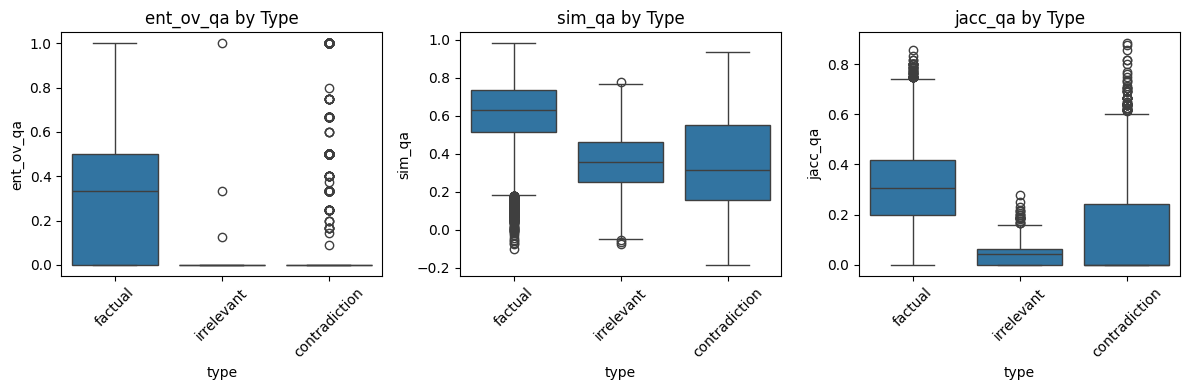

FIXED boxplots saved & displayed!


In [10]:
# QUICK VALIDATION PLOT (bonus: factual vs others)
plt.figure(figsize=(12, 4))
feats = ['ent_ov_qa', 'sim_qa', 'jacc_qa']
for i, feat in enumerate(feats, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df_nlp, x='type', y=feat)
    plt.title(f'{feat} by Type')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('nlp_feature_boxes_fixed.png', dpi=300, bbox_inches='tight')
plt.show()
print("FIXED boxplots saved & displayed!")

In [11]:
# =============================================================================
# STEP 3: TEXT VECTORIZATION + FINAL FEATURE MATRIX
# =============================================================================
# Combine all texts for TF-IDF (question [Q] answer [A] context)
df_nlp['text'] = (df_nlp['question'] + ' [Q] ' + 
                  df_nlp['answer'] + ' [A] ' + 
                  df_nlp['context'])

# TF-IDF on full text (unigrams + bigrams, top 5000 features)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_text = vectorizer.fit_transform(df_nlp['text'])

# Final feature matrix: TF-IDF + NLP numerical features (hybrid approach)
X_nlp = nlp_df.values  # 7 spaCy features
X = np.hstack([X_text.toarray(), X_nlp])  # Shape: (100, 5007)

y = df_nlp['label'].values

# Train-test split (stratified to preserve class ratios)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Train/Test split: {X_train.shape[0]}/{X_test.shape[0]}")




Feature matrix shape: (21021, 5007)
Train/Test split: 16816/4205


In [12]:
# =============================================================================
# STEP 4: HANDLE IMBALANCE + TRAIN MODELS
# Options tested: class weights, SMOTE oversampling, ensembles
# =============================================================================
# Compute class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# Apply SMOTE to training set only (oversample minorities)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Post-SMOTE train shape: {X_train_sm.shape} (balanced!)")

# Model 1: Logistic Regression (fast baseline + interpretable)
lr_model = LogisticRegression(max_iter=2000, class_weight=class_weight_dict, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

# Model 2: Random Forest (ensemble, handles imbalance well)
rf_model = RandomForestClassifier(n_estimators=200, class_weight=class_weight_dict, 
                                  max_depth=10, random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

print("Models trained: LR + RF")



Post-SMOTE train shape: (41832, 5007) (balanced!)
Models trained: LR + RF


In [13]:
# =============================================================================
# STEP 5: EVALUATE MODELS (Cross-val + Test set)
# =============================================================================
models = {'Logistic Regression': lr_model, 'Random Forest': rf_model}

for name, model in models.items():
    # Cross-validation (5-fold stratified)
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=StratifiedKFold(5), 
                               scoring='f1_macro')
    print(f"\n{name} CV F1-macro: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    
    # Test set predictions
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"{name} Test Accuracy: {acc:.3f} | F1-macro: {f1:.3f}")
    print(classification_report(y_test, y_pred, 
                               target_names=['factual', 'contradiction', 'irrelevant']))

# Confusion matrix for best model (RF usually wins)
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['factual', 'contradiction', 'irrelevant'],
            yticklabels=['factual', 'contradiction', 'irrelevant'])
plt.title('Confusion Matrix - Random Forest (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()
print("Confusion matrix saved: confusion_matrix.png")





Logistic Regression CV F1-macro: 0.897 (+/- 0.005)
Logistic Regression Test Accuracy: 0.752 | F1-macro: 0.641
               precision    recall  f1-score   support

      factual       0.98      0.74      0.84      3487
contradiction       0.27      0.75      0.40       364
   irrelevant       0.55      0.89      0.68       354

     accuracy                           0.75      4205
    macro avg       0.60      0.79      0.64      4205
 weighted avg       0.88      0.75      0.79      4205


Random Forest CV F1-macro: 0.526 (+/- 0.006)
Random Forest Test Accuracy: 0.152 | F1-macro: 0.231
               precision    recall  f1-score   support

      factual       0.00      0.00      0.00      3487
contradiction       0.09      0.83      0.17       364
   irrelevant       0.36      0.96      0.53       354

     accuracy                           0.15      4205
    macro avg       0.15      0.60      0.23      4205
 weighted avg       0.04      0.15      0.06      4205

Confusion matr

FIXED Feature importance saved!
      feature  importance
0      pos_ov    0.103191
1     jacc_qa    0.069233
2   ent_ov_qa    0.060751
3   ent_ov_ac    0.057392
4      sim_qa    0.055790
5      sim_ac    0.044920
6     neg_mis    0.017246
7   tfidf_479    0.016314
8  tfidf_1263    0.014698
9  tfidf_3025    0.013514


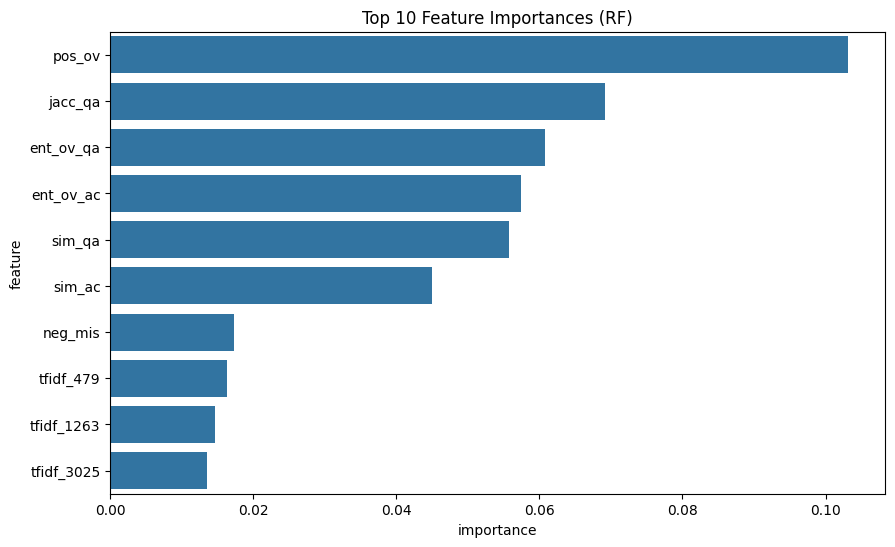

In [14]:
# FEATURE IMPORTANCE
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[-10:]  # Top 10 indices

# Get TF-IDF names for FIRST part of top_idx, NLP for LAST 7
tfidf_count = max(0, len(top_idx) - 7)  # How many TF-IDF features in top 10
nlp_features = ['ent_ov_qa', 'ent_ov_ac', 'pos_ov', 'sim_qa', 'sim_ac', 'jacc_qa', 'neg_mis']

# Build names correctly: TF-IDF indices first, then NLP names for last 7 positions
feat_names = []
for i, idx in enumerate(top_idx):
    if idx < X.shape[1] - 7:  # TF-IDF feature (first 3000-5000 cols)
        feat_names.append(f'tfidf_{idx}')
    else:  # NLP feature (last 7 cols)
        feat_names.append(nlp_features[idx - (X.shape[1] - 7)])

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances[top_idx]})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
imp_df.to_csv('feature_importance_fixed.csv', index=False)
print("FIXED Feature importance saved!")
print(imp_df)

# Quick plot
plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances (RF)')
plt.savefig('feature_importance_plot.png', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
# =============================================================================
# STEP 6: SAVE EVERYTHING FOR PRODUCTION/PREDICTIONS
# For test.json: Load test data, extract same features, predict with best model (RF)
# =============================================================================
# Save models + vectorizer + scaler (if any)
with open('factuality_model_rf.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('factuality_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('factuality_nlp_pipeline.pkl', 'wb') as f:  # Custom NLP func not picklable, but documented
    pickle.dump({'mapping': type_mapping}, f)

# Save full train results
test_results = pd.DataFrame({
    'true_label': y_test,
    'pred_label': y_pred_rf,
    'pred_type': [list(type_mapping.keys())[v] for v in y_pred_rf],
    'true_type': [list(type_mapping.keys())[v] for v in y_test]
})
test_results.to_csv('test_predictions.csv', index=False)




In [16]:
print("\nPROJECT COMPLETE!")
print("Artifacts generated:")
print("- cleaned_train_data.csv")
print("- nlp_features.csv")
print("- test_predictions.csv")
print("- feature_importance.csv")
print("- confusion_matrix.png")
print("- factuality_model_rf.pkl")
print("- factuality_vectorizer.pkl")
print("\nFor FULL 21k TRAIN + 2k TEST:")
print("1. Replace CSV path with 'data/train.csv'")
print("2. Load test: df_test = pd.read_json('data/test.json')")
print("3. Apply extract_nlp_features + vectorizer.transform")
print("4. preds = rf_model.predict(X_test_full)")
print("5. Submit preds as {id: pred_label} JSON")



PROJECT COMPLETE!
Artifacts generated:
- cleaned_train_data.csv
- nlp_features.csv
- test_predictions.csv
- feature_importance.csv
- confusion_matrix.png
- factuality_model_rf.pkl
- factuality_vectorizer.pkl

For FULL 21k TRAIN + 2k TEST:
1. Replace CSV path with 'data/train.csv'
2. Load test: df_test = pd.read_json('data/test.json')
3. Apply extract_nlp_features + vectorizer.transform
4. preds = rf_model.predict(X_test_full)
5. Submit preds as {id: pred_label} JSON
